# **Tugas - 8 Clustering menggunakan Fuzzy C Means**

In [1]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.13.0
    Uninstalling typer-0.13.0:
      Successfully uninstalled typer-0.13.0
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.27.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
df.head()

,judul,isi,tanggal,kategori,Hasil cleansing,Hasil case_folding,tokenize,Hasil stopword
0,Asian Esports Games 2024: Timnas Indonesia Mob...,Jakarta - Indonesia berhasil meraih juara di k...,"Rabu, 27 Nov 2024 21:13 WIB",Games,Jakarta Indonesia berhasil meraih juara di ko...,jakarta indonesia berhasil meraih juara di ko...,"['jakarta', 'indonesia', 'berhasil', 'meraih',...",jakarta indonesia berhasil meraih juara kompet...
1,"20 Game Android yang Diadaptasi dari Anime, Ad...",Jakarta - Sepertinya sederet game Android ini ...,"Selasa, 26 Nov 2024 20:04 WIB",Games,Jakarta Sepertinya sederet game Android ini a...,jakarta sepertinya sederet game android ini a...,"['jakarta', 'sepertinya', 'sederet', 'game', '...",jakarta sederet game android favorit wibu deh ...
2,"Jadwal M6 Mobile legends, Wakil Indonesia Main...","Jakarta - Setelah fase wild card berakhir, kes...","Selasa, 26 Nov 2024 14:10 WIB",Games,Jakarta Setelah fase wild card berakhir keser...,jakarta setelah fase wild card berakhir keser...,"['jakarta', 'setelah', 'fase', 'wild', 'card',...",jakarta fase wild card keseruan m mobile legen...
3,"Tips dan Cara Main Pokemon TCG Pocket, Pemula ...",Jakarta - Pokemon Trading Card Game (TCG) Pock...,"Selasa, 26 Nov 2024 12:40 WIB",Games,Jakarta Pokemon Trading Card Game TCG Pocket ...,jakarta pokemon trading card game tcg pocket ...,"['jakarta', 'pokemon', 'trading', 'card', 'gam...",jakarta pokemon trading card game tcg pocket s...
4,Indonesia Ikut Asian Esports Games 2024 Bangko...,Jakarta - Indonesia berpartisipasi dalam Asian...,"Selasa, 26 Nov 2024 09:06 WIB",Games,Jakarta Indonesia berpartisipasi dalam Asian ...,jakarta indonesia berpartisipasi dalam asian ...,"['jakarta', 'indonesia', 'berpartisipasi', 'da...",jakarta indonesia berpartisipasi asian esports...


In [4]:
texts = df['Hasil stopword']

In [5]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [6]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 4580)

In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.00001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9595247791972165, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.9479811150981223, ARI=0.002427096100870114, NMI=0.0513556720154113
Iterasi dengan n_components=4: Silhouette=0.9293261376667723, ARI=0.002427096100870114, NMI=0.0513556720154113
Iterasi dengan n_components=5: Silhouette=0.9101574255876987, ARI=0.008096346523631212, NMI=0.08068918390116896
Iterasi dengan n_components=6: Silhouette=0.8719832493795577, ARI=0.008096346523631212, NMI=0.08068918390116896
Iterasi dengan n_components=7: Silhouette=0.8493769598798722, ARI=0.012148896880163282, NMI=0.09456435533426642
Iterasi dengan n_components=8: Silhouette=0.8329456985117986, ARI=0.01701445012943135, NMI=0.10806496399729751
Iterasi dengan n_components=9: Silhouette=0.8060835227126902, ARI=0.02269374787246114, NMI=0.1212746751286823
Iterasi dengan n_components=10: Silhouette=0.7025385961316765, ARI=0.052993146457920554, NMI=0.12642709342764596
Iterasi deng

In [8]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9595247791972165
Best ARI is achieved by n_components=24 with score: 0.8824127248460211
Best NMI is achieved by n_components=24 with score: 0.8079616479391557


In [9]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9595247791972165

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9595247791972165, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.9479811150981223, 'ari': 0.002427096100870114, 'nmi': 0.0513556720154113}
n_components=4: Silhouette Score={'silhouette': 0.9293261376667723, 'ari': 0.002427096100870114, 'nmi': 0.0513556720154113}
n_components=5: Silhouette Score={'silhouette': 0.9101574255876987, 'ari': 0.008096346523631212, 'nmi': 0.08068918390116896}
n_components=6: Silhouette Score={'silhouette': 0.8719832493795577, 'ari': 0.008096346523631212, 'nmi': 0.08068918390116896}
n_components=7: Silhouette Score={'silhouette': 0.8493769598798722, 'ari': 0.012148896880163282, 'nmi': 0.09456435533426642}
n_components=8: Silhouette Score={'silhouette': 0.8329456985117986, 'ari': 0.01701445012943135, 'nmi': 0.10806496399729751}
n_components=9: Silhouette Score={'si

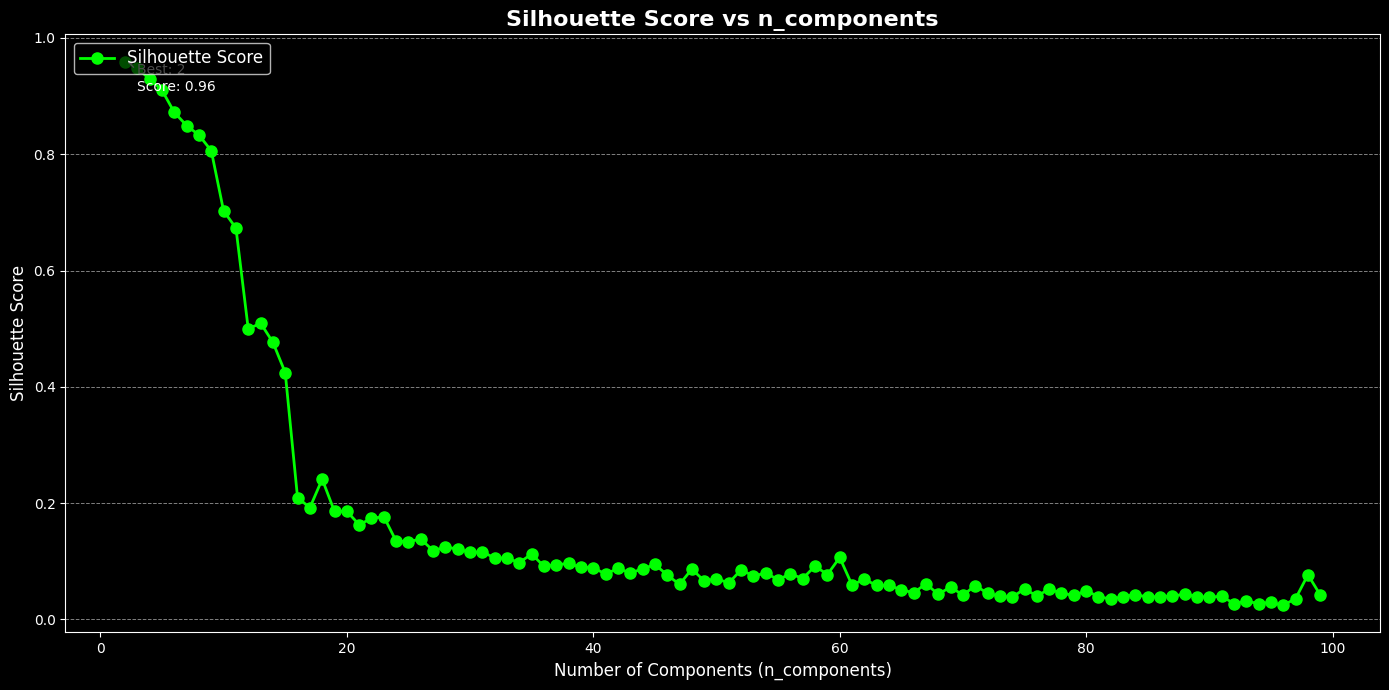

In [10]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

## Clustering

Silhouette Score: 0.1348
Jumlah data pada setiap cluster:
Cluster
1    51
0    49
Name: count, dtype: int64


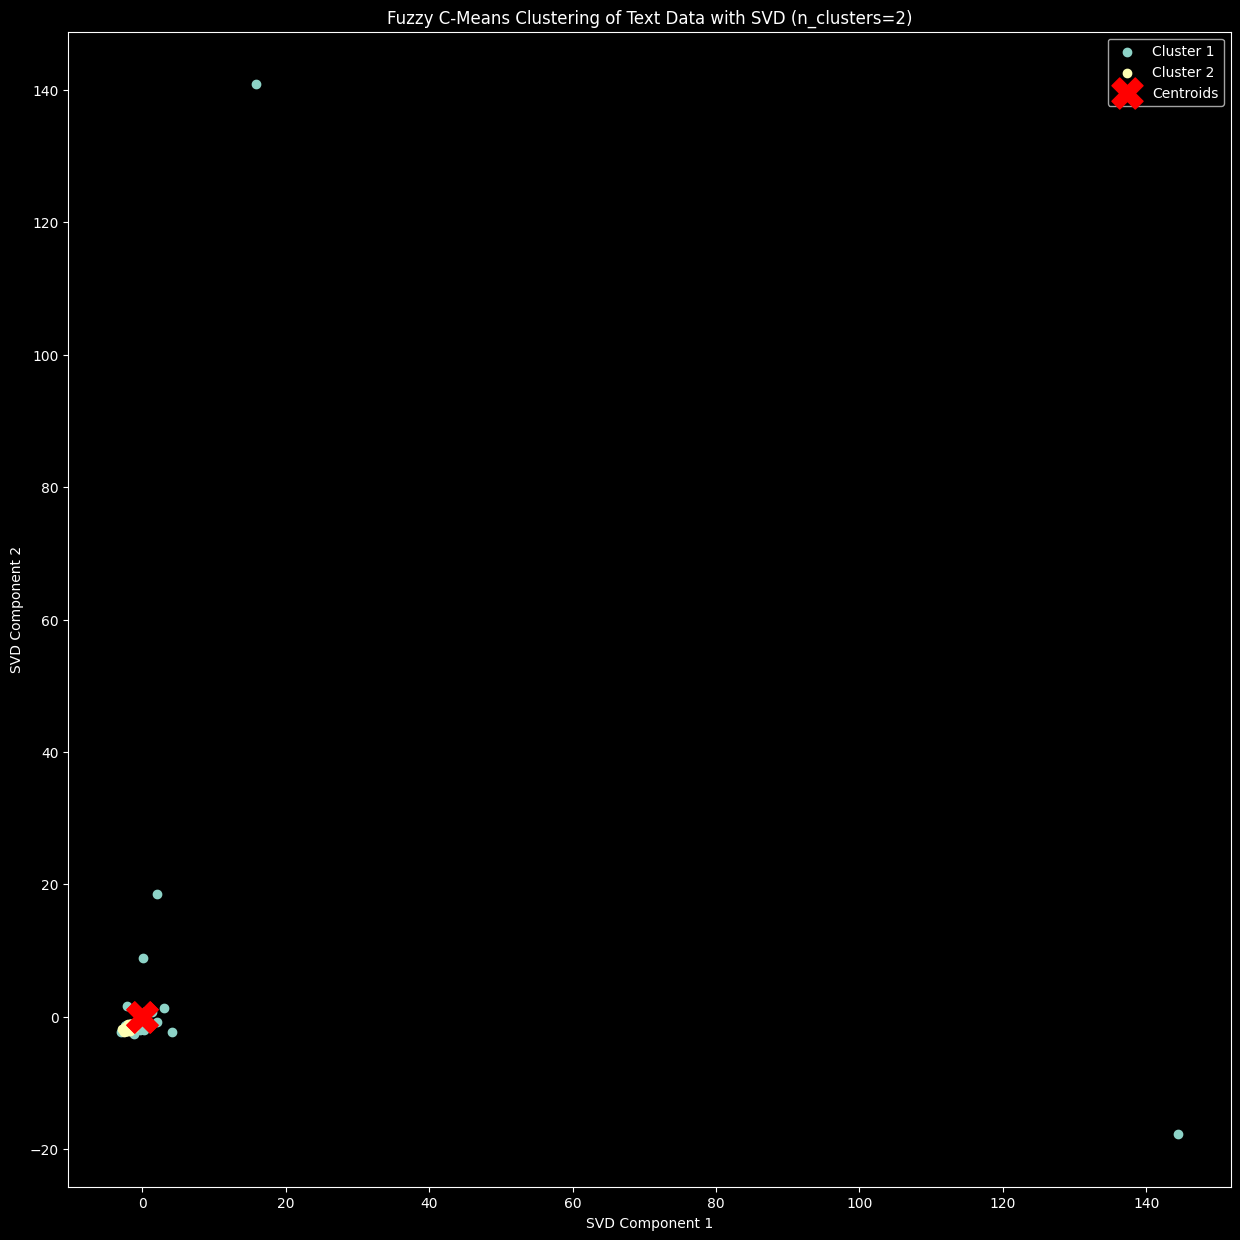

In [27]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')
data = df['Hasil stopword']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=24 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.00001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(15, 15))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=500, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [19]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

    id    kategori  Cluster
0    0       Games        0
1    1       Games        0
2    2       Games        0
3    3       Games        0
4    4       Games        0
..  ..         ...      ...
95  95  Sepak Bola        1
96  96  Sepak Bola        1
97  97  Sepak Bola        1
98  98  Sepak Bola        1
99  99  Sepak Bola        1

[100 rows x 3 columns]


In [20]:
# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

Anggota Cluster 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50]
Anggota Cluster 1: [33, 45, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


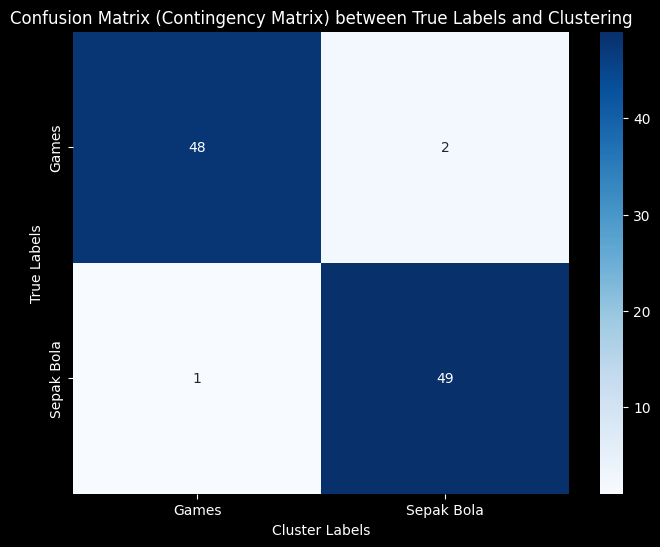

Confusion Matrix (Contingency Matrix):
[[48  2]
 [ 1 49]]


In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [22]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.1348


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')
data = df['Hasil stopword'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=2.0,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.00001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Membuat pipeline dengan FCM dan parameter yang diberikan
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=25)),  # Reduksi Dimensi
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))  # Menggunakan FCM melalui FunctionTransformer
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [24]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan (sudah dilabeli Games dan Sepakbola)
# Misalnya, kita memiliki data pelatihan yang dilabeli sebagai berikut:
df = pd.read_csv('/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv')  # Ganti dengan path data pelatihan Anda
data_pelatihan = df['Hasil stopword']  # Kolom yang berisi teks

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)  # Tanpa FCM, hanya TF-IDF, Scaling, dan SVD
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.00001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui (Games = 0, Sepakbola = 1)
# Misalnya, jika label pada data pelatihan adalah:
labels_train = df['kategori']  # Kolom label, yang bisa berisi 0 (Games) dan 1 (Sepakbola)

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)
# Misalkan cluster 0 harus menjadi Games dan cluster 1 harus menjadi Sepakbola
cluster_to_label = {0: 'Games', 1: 'Sepak bola'}

# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """
Sejak dirilis pada tahun 2016, Mobile Legends: Bang Bang terus menjadi salah satu game mobile terpopuler di dunia, termasuk di Indonesia. Komunitas pemain yang solid dan dukungan dari Moonton dalam mengembangkan konten baru menjadi kunci keberhasilan game ini bertahan di puncak persaingan
"""

# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Games
